# Geopack SDK: Data Analysis with GeoPandas
 
This notebook demonstrates how to load vector datasets from Geopack directly into **GeoPandas GeoDataFrames** for spatial analysis and visualization.
 
---
 
### 🚀 Setup Note
This notebook is configured to work both with an installed `geopack-sdk` package or directly from the repository source code (`src/` folder).
 
---

In [8]:
# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

import os
import sys
import geopandas as gpd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- SMART SOURCE IMPORT ---
# Ensures we use the local 'src' directory with high priority
try:
    current_dir = os.getcwd()
    source_path = os.path.abspath(os.path.join(current_dir, "..", "src"))
    if os.path.exists(source_path):
        if source_path not in sys.path:
            sys.path.insert(0, source_path)
        print(f"ℹ️ Using SDK from local source: {source_path}")
    else:
        print("ℹ️ Using SDK from installed site-packages (pip)")
except Exception:
    print("⚠️ Could not determine local source path, falling back to pip.")

from geopack_sdk import GeopackClient

load_dotenv()
client = GeopackClient(base_url=os.getenv("GEOPACK_API_URL", "http://localhost:3000/api"))

# Login using credentials from .env or defaults
try:
    client.auth.login(
        os.getenv("GEOPACK_USERNAME", "admin"), 
        os.getenv("GEOPACK_PASSWORD", "password")
    )
    print("✅ Login successful!")
except Exception as e:
    print(f"❌ Login failed: {e}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ℹ️ Using SDK from local source: d:\Works\geopack-geoportal\geopack-geoportal-v2\python-sdk\src
✅ Login successful!


## 1. Finding a Vector Dataset
We use the filtering system to find a suitable vector dataset.

In [9]:
# 1. List available vector datasets
vector_datasets = client.datasets.list(page_size=50, active_filters={"dataType": "vector"})

if not vector_datasets:
    print("❌ No vector datasets found. Please upload a shapefile or geojson first.")
else:
    print(f"Available Vector Datasets ({len(vector_datasets)}):")
    for ds in vector_datasets:
        #print(f"- [{ds['id']}] {ds['name']} (Type: {ds['dataType']})")
        print(f"- [{ds['id']}] {ds['name']}  ({ds.get('dataType', 'N/A')} {ds.get('subType', '')}) [{ds.get('dataStore', {}).get('name', 'N/A')}]")


    # --- SELECT YOUR DATASET HERE ---
    # You can change this ID to any of the IDs listed above
    SELECTED_DATASET_ID = vector_datasets[0]['id']
    print(f"\n✅ Selected Dataset ID: {SELECTED_DATASET_ID}")


Available Vector Datasets (50):
- [2362] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2361] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2360] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2359] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2357] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2342] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2341] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2340] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2339] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2338] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2337] Rural_District.shp  (vector MultiPolygon) [Default Filesystem GDB]
- [2293] مکانیابی احداث پارکینگ دوچرخه  (vector MultiPolygon) [Default Filesystem GDB]
- [2258] suitability  (vector MultiPolygon) [

## 2. Converting to GeoDataFrame
The `to_geodataframe()` method handles the GeoJSON fetching and conversion automatically, including CRS assignment.

In [10]:
# 2. Fetch metadata and data
# We fetch the target dataset object first using the selected ID
SELECTED_DATASET_ID=1829
target_ds = client.datasets.get(SELECTED_DATASET_ID)

# Convert to GeoDataFrame
gdf = client.datasets.to_geodataframe(SELECTED_DATASET_ID, limit=500)

print(f"Loaded {len(gdf)} features from '{target_ds['name']}'.")
print(f"CRS: {gdf.crs}")
gdf.head()


Loaded 156 features from 'Rck_Typ'.
CRS: EPSG:32640


,geometry,age1,age2,abbrev,origin,acidity,texture,format_bo,comment_en,comment_fa,rock_type1,rock_type2,rock_type3,shape_area,shape_length
0,"MULTIPOLYGON (((675957.812 3126299.998, 675953...",42,NaN,ATU,4.0,None,None,None,Andesitic tuff,None,143,NaN,NaN,21864.906524,1393.978528
1,"MULTIPOLYGON (((675957.812 3126299.998, 675976...",30,NaN,QSC,NaN,None,None,None,Scree,None,101,NaN,NaN,2609.110190,239.048387
2,"MULTIPOLYGON (((675976.936 3126299.998, 675991...",30,NaN,ALL,NaN,None,None,None,Recent Alluvium,None,3,NaN,NaN,8986.771535,1559.447048
3,"MULTIPOLYGON (((675991.499 3126299.998, 676070...",51,47.0,MGR1,6.0,None,None,None,Micro granite,None,174,NaN,NaN,26061.802213,1063.442860
4,"MULTIPOLYGON (((676076.936 3126299.998, 676100...",51,47.0,MGR1,6.0,None,None,None,Micro granite,None,174,NaN,NaN,3885.919460,381.557517


## 3. Spatial Analysis & Visualization
Now we can use native GeoPandas and Matplotlib functions.

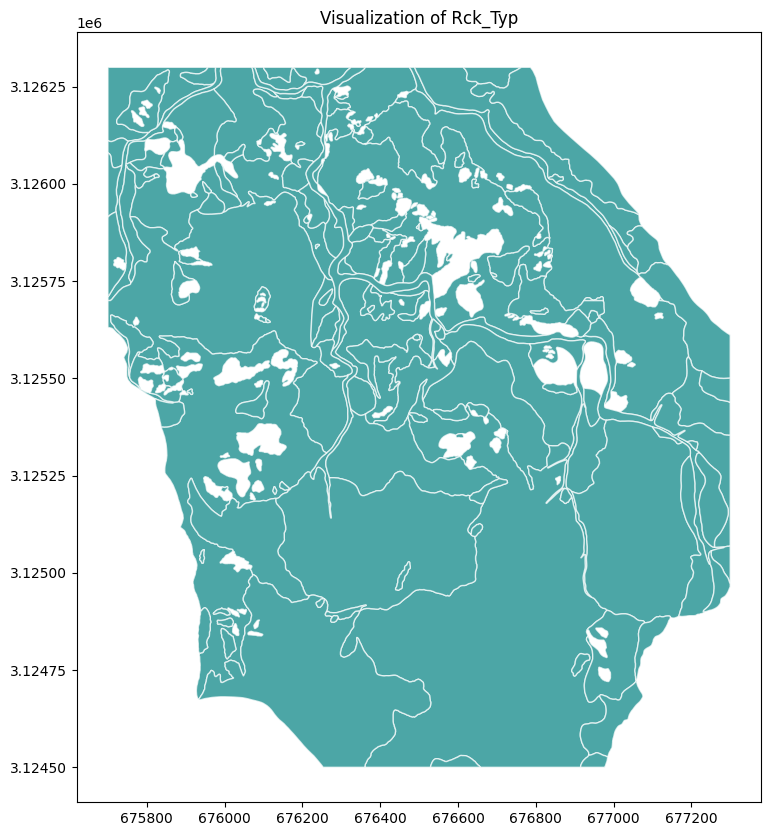

In [11]:
# Plot the data
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='teal', edgecolor='white', alpha=0.7)
ax.set_title(f"Visualization of {target_ds['name']}")
plt.show()

## 4. Basic Statistics
Analyze the attributes of the spatial data.

In [12]:
# Display area statistics (if polygons)
if 'area' in gdf.columns or 'shape_area' in gdf.columns:
    area_col = 'area' if 'area' in gdf.columns else 'shape_area'
    print(f"Average Area: {gdf[area_col].mean():.2f}")
else:
    print("Attribute columns summary:")
    print(gdf.describe())

Average Area: 14274.53
